In [22]:
train_path = '/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets/train/'
test_path  = '/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets/test/'

# !du --inodes '../input/paddy-doctor-diseases-v2/train_images/'
# !du --inodes '../input/paddy-doctor-diseases-v2/test_images/'

import glob
from pathlib import Path

print('train images')
for filepath in glob.glob(train_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")
    
print('test images')
for filepath in glob.glob(test_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")

# files = glob.glob(test_path + '/*')
# print(f"{len(files)} \t {Path(test_path).name}") 

train images
1600 	 tungro
1600 	 yellow_stem_borer
1600 	 hispa
1601 	 downy_mildew
1600 	 black_stem_borer
1600 	 bacterial_leaf_streak
1599 	 bacterial_leaf_blight
1601 	 brown_spot
1600 	 blast
1600 	 leaf_roller
1599 	 normal
1599 	 bacterial_panicle_blight
1601 	 white_stem_borer
test images
400 	 tungro
400 	 yellow_stem_borer
400 	 hispa
399 	 downy_mildew
400 	 black_stem_borer
400 	 bacterial_leaf_streak
401 	 bacterial_leaf_blight
399 	 brown_spot
400 	 blast
400 	 leaf_roller
401 	 normal
401 	 bacterial_panicle_blight
399 	 white_stem_borer


In [23]:
import numpy as np
import pandas as pd
import pickle
import cv2
import os

from os import listdir
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense

from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from keras.preprocessing import image
from keras.preprocessing.image import img_to_array
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import keras
keras.__version__
from psutil import virtual_memory

SEED = 123
EPOCHS = 100
INIT_LR = 1e-3
BS = 32
default_image_size = tuple((256, 256))
image_size = 0
width = 256
height = 256
depth = 3

n_classes = len(glob.glob(train_path + '/*/'))
print(n_classes)

13


channels_last


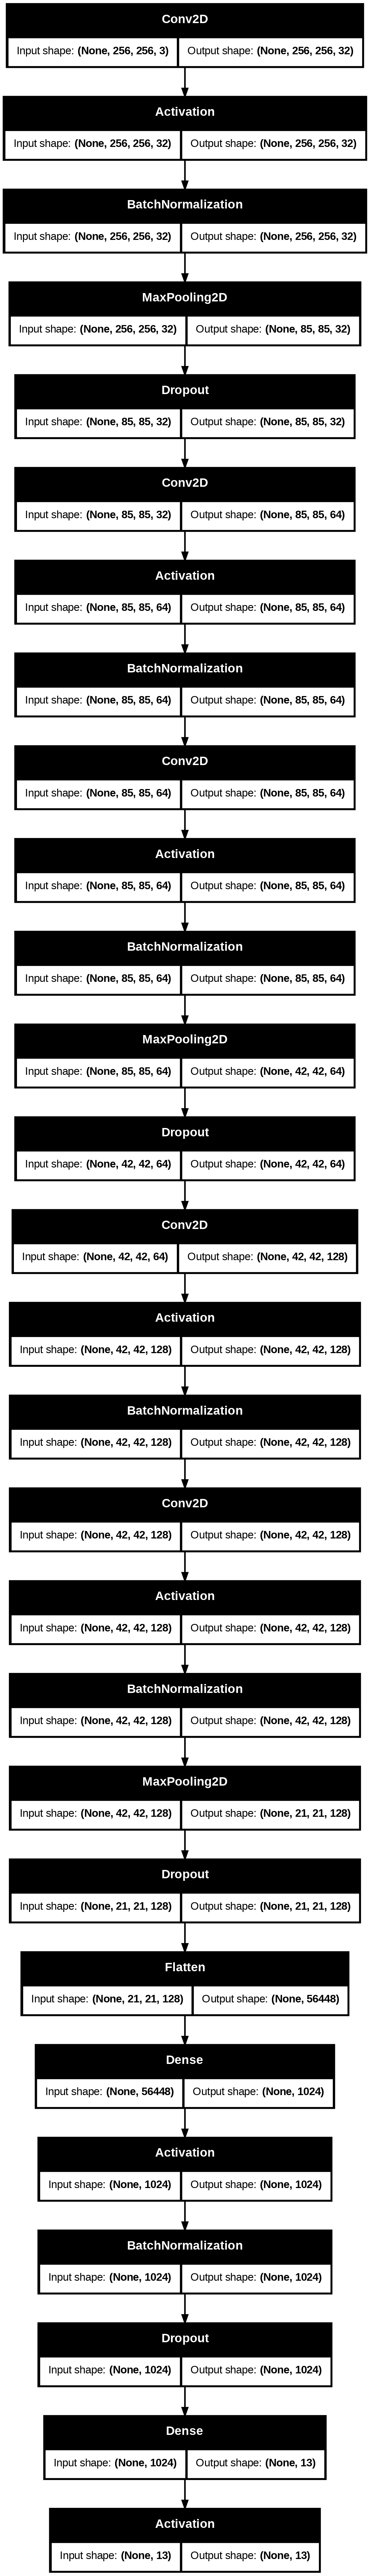

In [24]:
def get_model():
    model = Sequential()
    inputShape = (height, width, depth)
    chanDim = -1
    print(K.image_data_format())
    if K.image_data_format() == "channels_first":
        inputShape = (depth, height, width)
        chanDim = 1
    model.add(Conv2D(32, (3, 3), padding="same",input_shape=inputShape))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(3, 3)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(Conv2D(64, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(128, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(Conv2D(128, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1024))
    model.add(Activation("relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(n_classes))
    model.add(Activation("softmax"))
    
    opt = Adam(learning_rate=INIT_LR)

    # distribution
    model.compile(loss="binary_crossentropy", optimizer=opt,metrics=["accuracy"])
    return model
model = get_model()

plot_model(model, '/kaggle/working/model.png', show_shapes=True)

In [25]:
image_datagen = ImageDataGenerator(featurewise_center=False,
                 samplewise_center=False,
                 featurewise_std_normalization=False,
                 samplewise_std_normalization=False,
                 zca_whitening=False,
                 rotation_range=5,
                 shear_range=0.2,
                 zoom_range=0.2,
                 width_shift_range=0.05,
                 height_shift_range=0.05,
                 channel_shift_range=0.,
                 fill_mode='nearest',
                 horizontal_flip=True,
                 vertical_flip=False,
                 rescale=1./255,
                                   validation_split=0.2)

train_generator = image_datagen.flow_from_directory(    
    directory = train_path,
    subset='training',
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED)

valid_generator = image_datagen.flow_from_directory(    
    directory=train_path,
    subset='validation',
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(    
    directory=test_path,
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=1,
    #classes=['.'],
    class_mode="categorical",
    #class_mode=None,
    shuffle=False,
    seed=SEED)

print(train_generator.class_indices)

print(train_generator.samples, valid_generator.samples, test_generator.samples, )

Found 16643 images belonging to 13 classes.
Found 4157 images belonging to 13 classes.
Found 5200 images belonging to 13 classes.
{'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'black_stem_borer': 3, 'blast': 4, 'brown_spot': 5, 'downy_mildew': 6, 'hispa': 7, 'leaf_roller': 8, 'normal': 9, 'tungro': 10, 'white_stem_borer': 11, 'yellow_stem_borer': 12}
16643 4157 5200


In [26]:
import wandb

wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21")

run = wandb.init(
    project="project-ablations",  # Customize as needed
    name="CNN",
    config={
        "epochs": 100,
        "base_lr": 0.005,
        "weight_decay": 0.01,
        "architecture": "CNN"
    },
    reinit=True
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▅█▁▅█
train_accuracy,▁▇█▁▇█
train_loss,█▃▁█▃▁
val_accuracy,▅█▁▅█▁
val_loss,█▁▅█▁▅
epoch,3
train_accuracy,0.55716
train_loss,0.17507
val_accuracy,0.28828
val_loss,0.27172


In [27]:
!pip install livelossplot

from livelossplot.inputs.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


plot_loss_1 = PlotLossesCallback()


tl_checkpoint_1 = ModelCheckpoint(
    filepath='cnn_best.weights.h5',  # can keep this extension
    save_weights_only=True,            # tell Keras you're only saving weights
    save_best_only=True,
    verbose=1
)

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           mode='min')

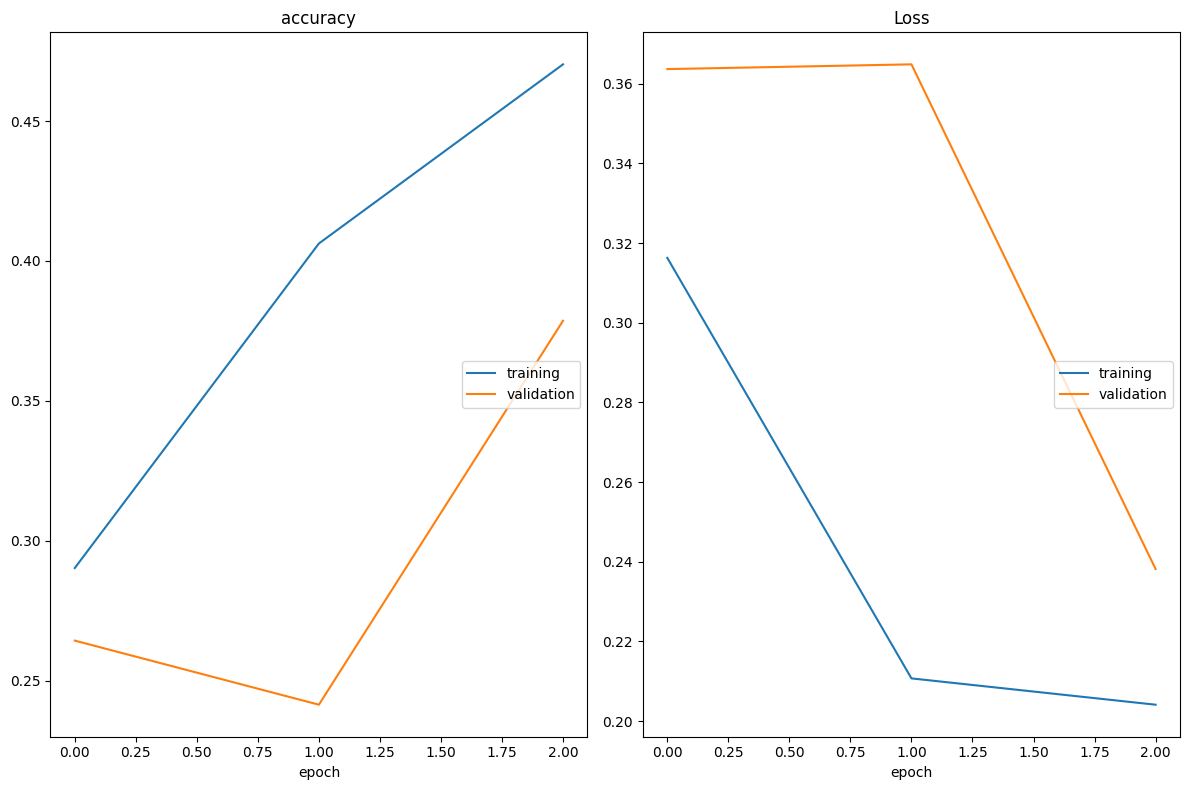

accuracy
	training         	 (min:    0.290, max:    0.470, cur:    0.470)
	validation       	 (min:    0.241, max:    0.379, cur:    0.379)
Loss
	training         	 (min:    0.204, max:    0.316, cur:    0.204)
	validation       	 (min:    0.238, max:    0.365, cur:    0.238)
520/520 ━━━━━━━━━━━━━━━━━━━━ 330s 629ms/step - accuracy: 0.4400 - loss: 0.2161 - val_accuracy: 0.3786 - val_loss: 0.2382


In [28]:
# %%time

STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size

# Retrain model with fine-tuning
history = model.fit(
    x=train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=valid_generator,
    validation_steps=STEP_SIZE_VALID,
    callbacks=[tl_checkpoint_1, early_stop, plot_loss_1],
    verbose=1,
    epochs=EPOCHS
)


# %%time
# STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
# STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size
# history = model.fit_generator(generator = train_generator,
#                     steps_per_epoch = STEP_SIZE_TRAIN,
#                     validation_data = valid_generator,
#                     validation_steps = STEP_SIZE_VALID,
#                     epochs=EPOCHS)

In [29]:
# Save model weights to a file
model.save_weights("cnn_best.weights.h5")

# Log weights file to W&B
wandb.save("cnn_best.weights.h5")

['/kaggle/working/wandb/run-20250422_141318-7bjvn6da/files/cnn_best.weights.h5']

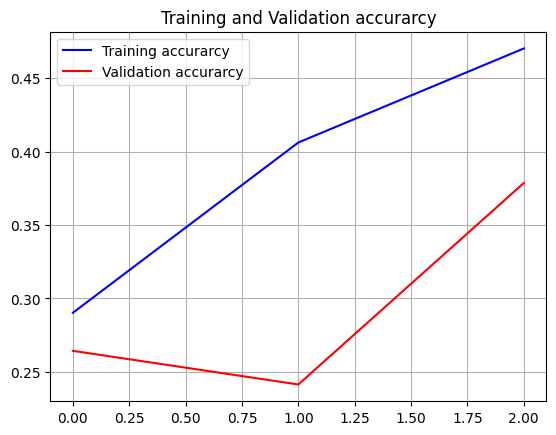

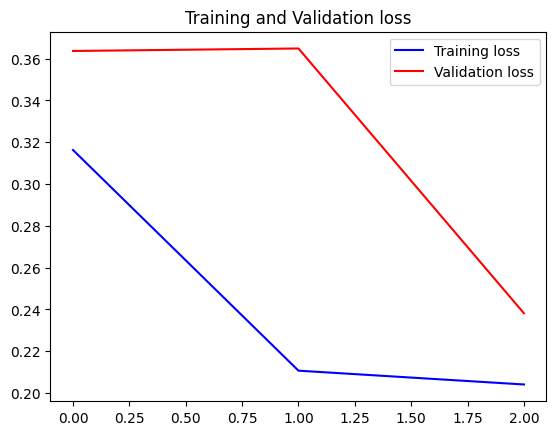

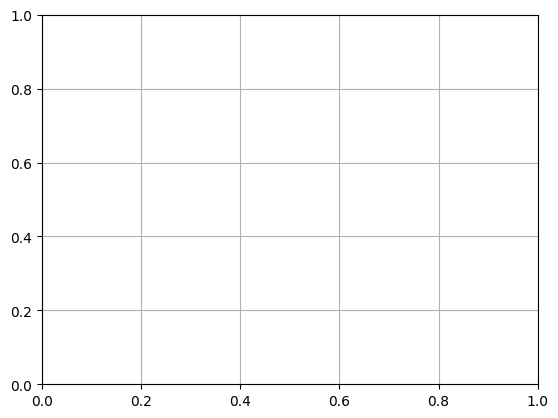

In [30]:
# %%time
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

# Log to W&B
for epoch in range(len(acc)):
    wandb.log({
        "train_accuracy": acc[epoch],
        "val_accuracy": val_acc[epoch],
        "train_loss": loss[epoch],
        "val_loss": val_loss[epoch],
        "epoch": epoch + 1
    })
    
#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.legend()
plt.grid(True)
plt.savefig("accuracy_plot.png")
wandb.log({"accuracy_plot": wandb.Image("accuracy_plot.png")})

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()
plt.show()
plt.grid(True)
plt.savefig("loss_plot.png")
wandb.log({"loss_plot": wandb.Image("loss_plot.png")})

In [31]:
print('test images')
for filepath in glob.glob(test_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")
    
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(    
    directory=test_path,
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=1,
    #classes=['.'],
    class_mode="categorical",
    # class_mode=None,
    shuffle=False,
    seed=SEED)

test images
400 	 tungro
400 	 yellow_stem_borer
400 	 hispa
399 	 downy_mildew
400 	 black_stem_borer
400 	 bacterial_leaf_streak
401 	 bacterial_leaf_blight
399 	 brown_spot
400 	 blast
400 	 leaf_roller
401 	 normal
401 	 bacterial_panicle_blight
399 	 white_stem_borer
Found 5200 images belonging to 13 classes.


In [32]:
STEP_SIZE_TEST=test_generator.n//test_generator.batch_size
test_generator.reset()

model.load_weights('cnn_best.weights.h5')
pred = model.predict(test_generator,
                     steps=STEP_SIZE_TEST,
                     verbose=1)

pred_classes = np.argmax(pred, axis=1)

5200/5200 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step


In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

class_names = test_generator.class_indices.keys()
true_classes = test_generator.classes

acc = accuracy_score(true_classes, pred_classes)
print("CNN Model Accuracy : {:.2f}%".format(acc * 100))

cls_report = classification_report(true_classes, pred_classes, 
                                   target_names=class_names, digits=5)
print(cls_report)

CNN Model Accuracy : 45.73%
                          precision    recall  f1-score   support

   bacterial_leaf_blight    0.27000   0.47132   0.34332       401
   bacterial_leaf_streak    0.78125   0.62500   0.69444       400
bacterial_panicle_blight    0.73256   0.62843   0.67651       401
        black_stem_borer    0.97183   0.51750   0.67537       400
                   blast    0.37028   0.36750   0.36888       400
              brown_spot    0.37619   0.39599   0.38584       399
            downy_mildew    0.26714   0.75188   0.39422       399
                   hispa    0.48588   0.21500   0.29809       400
             leaf_roller    0.60088   0.34250   0.43631       400
                  normal    0.48548   0.29177   0.36449       401
                  tungro    0.65882   0.28000   0.39298       400
        white_stem_borer    0.49819   0.34586   0.40828       399
       yellow_stem_borer    0.48305   0.71250   0.57576       400

                accuracy                      

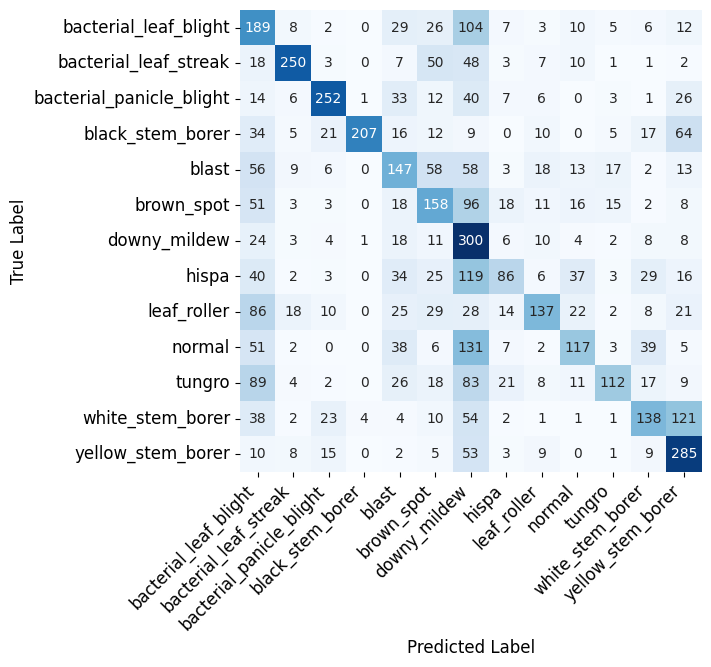

[[189   8   2   0  29  26 104   7   3  10   5   6  12]
 [ 18 250   3   0   7  50  48   3   7  10   1   1   2]
 [ 14   6 252   1  33  12  40   7   6   0   3   1  26]
 [ 34   5  21 207  16  12   9   0  10   0   5  17  64]
 [ 56   9   6   0 147  58  58   3  18  13  17   2  13]
 [ 51   3   3   0  18 158  96  18  11  16  15   2   8]
 [ 24   3   4   1  18  11 300   6  10   4   2   8   8]
 [ 40   2   3   0  34  25 119  86   6  37   3  29  16]
 [ 86  18  10   0  25  29  28  14 137  22   2   8  21]
 [ 51   2   0   0  38   6 131   7   2 117   3  39   5]
 [ 89   4   2   0  26  18  83  21   8  11 112  17   9]
 [ 38   2  23   4   4  10  54   2   1   1   1 138 121]
 [ 10   8  15   0   2   5  53   3   9   0   1   9 285]]


In [34]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the ten classes
class_names = test_generator.class_indices.keys()

def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        xticklabels=class_names, 
        yticklabels=class_names,
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    #ax.set_title(title, fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

plot_heatmap(true_classes, pred_classes, class_names, ax, title="CNN")    

#fig.suptitle("Confusion Matrix Model Comparison", fontsize=12)
#fig.tight_layout()
#fig.subplots_adjust(top=1.25)
plt.show()
cm = confusion_matrix(true_classes, pred_classes)
print(cm)

In [35]:
loss, acc = model.evaluate(test_generator, steps=STEP_SIZE_TEST, verbose=1)
print(acc, loss)

5200/5200 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.5035 - loss: 0.2019
0.45730769634246826 0.21461014449596405


In [36]:
pd.Series(train_generator.classes).value_counts()

5     1281
6     1281
11    1281
1     1280
0     1280
4     1280
3     1280
2     1280
7     1280
8     1280
9     1280
10    1280
12    1280
Name: count, dtype: int64

In [37]:
pd.Series(test_generator.classes).value_counts()

0     401
2     401
9     401
3     400
1     400
4     400
8     400
10    400
7     400
12    400
6     399
5     399
11    399
Name: count, dtype: int64

In [38]:
predicted_class_indices=np.argmax(pred,axis=1)
labels = (train_generator.class_indices)

labels = {v: k for k, v in train_generator.class_indices.items()}

predictions = [labels[k] for k in predicted_class_indices]

pd.Series(predictions).value_counts()

downy_mildew                1123
bacterial_leaf_blight        700
yellow_stem_borer            590
brown_spot                   420
blast                        397
bacterial_panicle_blight     344
bacterial_leaf_streak        320
white_stem_borer             277
normal                       241
leaf_roller                  228
black_stem_borer             213
hispa                        177
tungro                       170
Name: count, dtype: int64

In [39]:
filenames=test_generator.filenames

results=pd.DataFrame({"image_id":filenames,
                      "label":predictions})
results['image_id'] = results['image_id'].apply(lambda x: os.path.basename(x))
results.to_csv("submission.csv",index=False)
results.head()

,image_id,label
0,PDD00002_001.jpg,bacterial_leaf_blight
1,PDD00002_003.jpg,bacterial_leaf_streak
2,PDD00005_002.jpg,bacterial_leaf_blight
3,PDD00005_004.jpg,downy_mildew
4,PDD00006_003.jpg,blast


In [40]:
# Log to W&B
wandb.save("submission.csv")

['/kaggle/working/wandb/run-20250422_141318-7bjvn6da/files/submission.csv']